In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Loading

In [16]:
df = pd.read_csv("../sample_data/accidents_sample.csv")

In [17]:
df.head()

,Unnamed: 0,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,294815,20063102D0279,460210.0,345330.0,-1.104237,53.001892,31,3,2,1,...,No physical crossing within 50 meters,Darkness: Street lighting unknown,Unknown,Normal,NaN,NaN,1,No,E01028180,2006
1,33887,200906B023849,384700.0,395130.0,-2.231870,53.452693,6,3,2,1,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Raining without high winds,Wet/Damp,Road surface defective,Pedestrian in carriageway (not injured),1,No,E01005242,2009
2,112945,200943W220129,481850.0,168770.0,-0.824485,51.411999,43,3,2,1,...,non-junction pedestrian crossing,Darkness: Street lights present and lit,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,E01016696,2009
3,111245,201232N036612,506620.0,358600.0,-0.408496,53.113915,32,3,2,1,...,No physical crossing within 50 meters,Daylight: Street light present,Other,Frost/Ice,NaN,NaN,2,Yes,E01026180,2012
4,141451,2.00953E+12,385160.0,189050.0,-2.215673,51.600046,53,1,2,2,...,No physical crossing within 50 meters,Daylight: Street light present,Fog or mist,Wet/Damp,NaN,NaN,2,Yes,E01022206,2009


Data Cleaning

In [18]:
df.shape

(2000, 33)

In [19]:
df.columns

Index(['Unnamed: 0', 'Accident_Index', 'Location_Easting_OSGR',
       'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force',
       'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties',
       'Date', 'Day_of_Week', 'Time', 'Local_Authority_(District)',
       'Local_Authority_(Highway)', '1st_Road_Class', '1st_Road_Number',
       'Road_Type', 'Speed_limit', 'Junction_Control', '2nd_Road_Class',
       '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'LSOA_of_Accident_Location', 'Year'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 33 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Unnamed: 0                                   2000 non-null   int64  
 1   Accident_Index                               2000 non-null   object 
 2   Location_Easting_OSGR                        1999 non-null   float64
 3   Location_Northing_OSGR                       2000 non-null   float64
 4   Longitude                                    1999 non-null   float64
 5   Latitude                                     2000 non-null   float64
 6   Police_Force                                 2000 non-null   int64  
 7   Accident_Severity                            2000 non-null   int64  
 8   Number_of_Vehicles                           2000 non-null   int64  
 9   Number_of_Casualties                         2000 non-null   int64  
 10  

In [21]:
df.isnull().sum()

Unnamed: 0                                        0
Accident_Index                                    0
Location_Easting_OSGR                             1
Location_Northing_OSGR                            0
Longitude                                         1
Latitude                                          0
Police_Force                                      0
Accident_Severity                                 0
Number_of_Vehicles                                0
Number_of_Casualties                              0
Date                                              0
Day_of_Week                                       0
Time                                              0
Local_Authority_(District)                        0
Local_Authority_(Highway)                         0
1st_Road_Class                                    0
1st_Road_Number                                   0
Road_Type                                         0
Speed_limit                                       0
Junction_Con

In [22]:
df.describe()

,Unnamed: 0,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Speed_limit,2nd_Road_Class,2nd_Road_Number,Urban_or_Rural_Area,Year
count,2000.000000,1999.000000,2.000000e+03,1999.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,244259.160000,434333.816908,3.055787e+05,-1.512691,52.613595,30.441500,2.831000,1.845500,1.340500,4.127000,350.138500,4.073500,998.960500,39.265000,2.77600,368.310500,1.361000,2009.301000
std,149773.508064,94761.952009,1.627132e+05,1.391711,1.878568,25.823148,0.403138,0.711957,0.723064,1.894641,261.567959,1.408932,1827.657476,14.177809,3.19702,1292.611863,0.481451,2.968637
min,239.000000,139050.000000,0.000000e+00,-5.652215,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,20.000000,-1.00000,-1.000000,1.000000,2005.000000
25%,116273.000000,370300.000000,1.798425e+05,-2.443866,51.505498,6.000000,3.000000,1.000000,1.000000,3.000000,112.000000,3.000000,0.000000,30.000000,-1.00000,0.000000,1.000000,2006.000000
50%,233404.500000,433080.000000,2.815700e+05,-1.504781,52.430923,30.000000,3.000000,2.000000,1.000000,4.000000,320.000000,4.000000,109.500000,30.000000,3.00000,0.000000,1.000000,2009.000000
75%,370224.500000,518090.000000,4.040400e+05,-0.292138,53.532716,45.000000,3.000000,2.000000,1.000000,6.000000,517.000000,6.000000,690.000000,50.000000,6.00000,0.000000,2.000000,2012.000000
max,569717.000000,654000.000000,1.141600e+06,1.739756,60.156245,98.000000,3.000000,12.000000,9.000000,7.000000,940.000000,6.000000,9143.000000,70.000000,6.00000,9562.000000,3.000000,2014.000000


In [23]:
df["Accident_Severity"].value_counts()

Accident_Severity
3    1684
2     294
1      22
Name: count, dtype: int64

In [24]:
df = df.drop(columns=["Unnamed: 0"])

In [25]:
df.columns

Index(['Accident_Index', 'Location_Easting_OSGR', 'Location_Northing_OSGR',
       'Longitude', 'Latitude', 'Police_Force', 'Accident_Severity',
       'Number_of_Vehicles', 'Number_of_Casualties', 'Date', 'Day_of_Week',
       'Time', 'Local_Authority_(District)', 'Local_Authority_(Highway)',
       '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit',
       'Junction_Control', '2nd_Road_Class', '2nd_Road_Number',
       'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'LSOA_of_Accident_Location', 'Year'],
      dtype='object')

In [26]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

In [27]:
df["Date"].head()

0   2006-02-07
1   2009-11-04
2   2009-12-23
3   2012-02-10
4   2009-11-11
Name: Date, dtype: datetime64[ns]

Exploratory Data Analysis

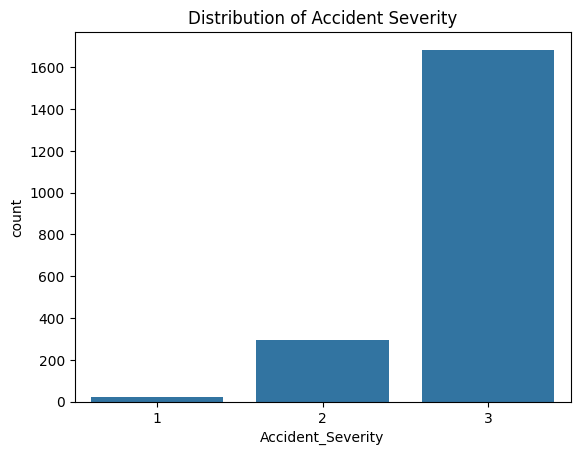

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Accident_Severity", data=df)
plt.title("Distribution of Accident Severity")
plt.show()

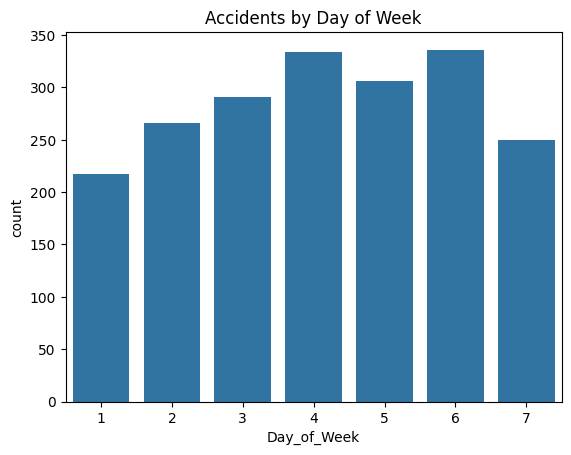

In [29]:
sns.countplot(x="Day_of_Week", data=df)
plt.title("Accidents by Day of Week")
plt.show()

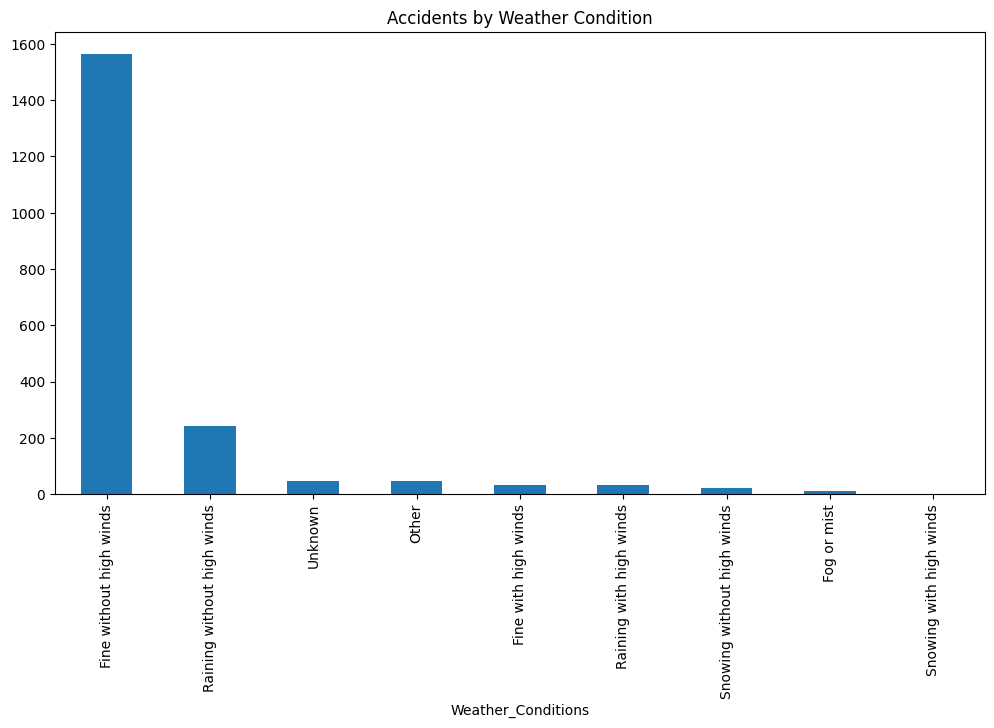

In [30]:
plt.figure(figsize=(12,6))
df["Weather_Conditions"].value_counts().plot(kind="bar")
plt.title("Accidents by Weather Condition")
plt.show()

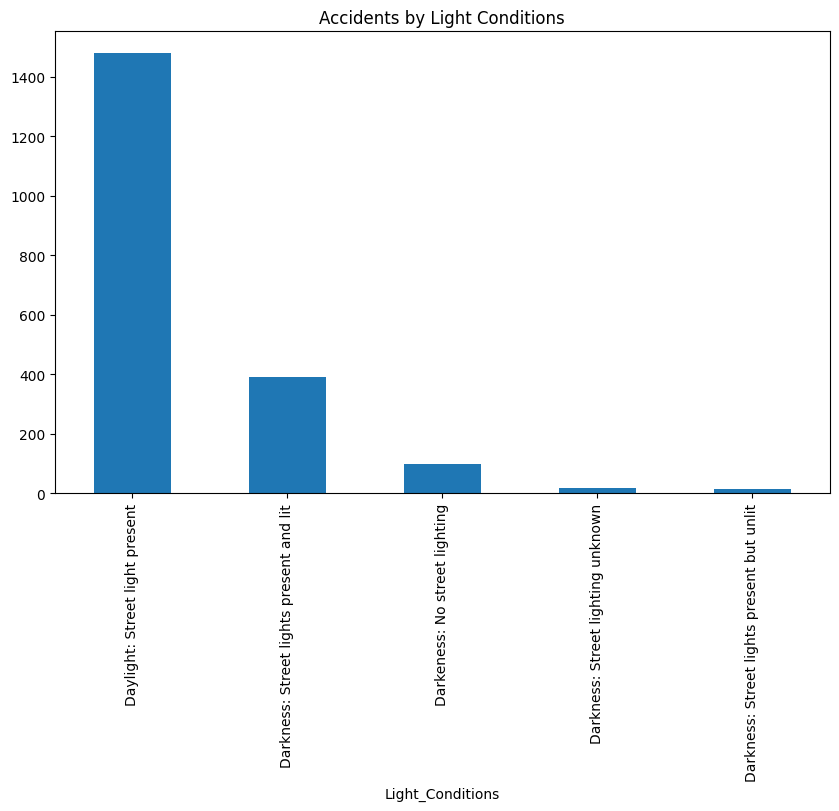

In [31]:
plt.figure(figsize=(10,6))
df["Light_Conditions"].value_counts().plot(kind="bar")
plt.title("Accidents by Light Conditions")
plt.show()

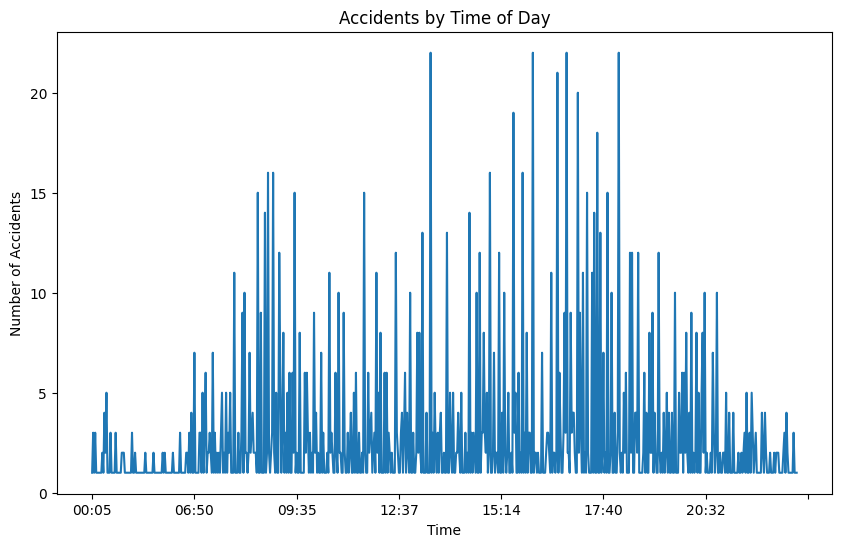

In [32]:
plt.figure(figsize=(10,6))
df["Time"].value_counts().sort_index().plot()
plt.title("Accidents by Time of Day")
plt.xlabel("Time")
plt.ylabel("Number of Accidents")
plt.show()

In [33]:
df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M").dt.hour

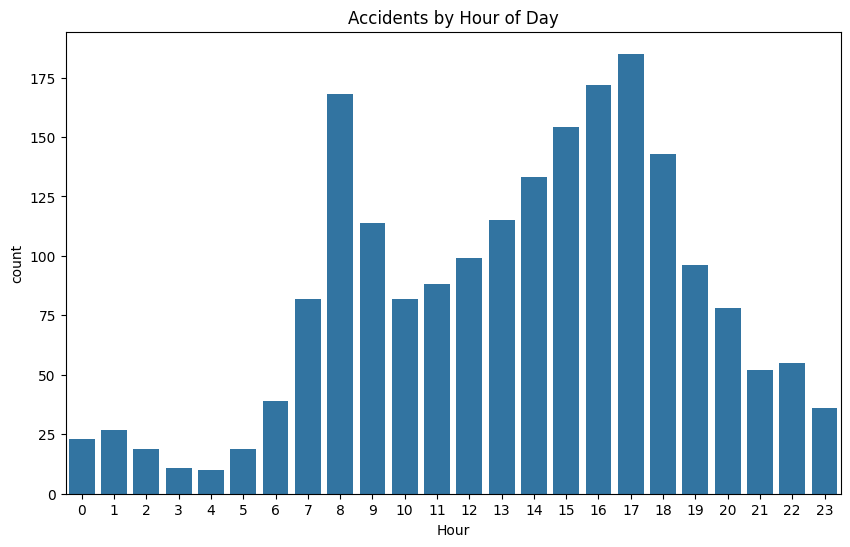

In [34]:
plt.figure(figsize=(10,6))
sns.countplot(x="Hour", data=df)
plt.title("Accidents by Hour of Day")
plt.show()

Applying Feature Engineering

In [35]:
df["Rush_Hour"] = df["Hour"].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 18) else 0)

1 - rush hour
0 - normal traffic

In [36]:
df["Night"] = df["Hour"].apply(lambda x: 1 if (x >= 20 or x <= 5) else 0)

1 = night driving
0 = daytime

In [37]:
df["Weekend"] = df["Day_of_Week"].apply(lambda x: 1 if x in [1,7] else 0)

1 = Saturday/Sunday
0 = weekday

In [38]:
df[["Hour","Rush_Hour","Night","Weekend"]].head()

,Hour,Rush_Hour,Night,Weekend
0,18,1,0,0
1,17,1,0,0
2,16,1,0,0
3,8,1,0,0
4,7,1,0,0


In [39]:
df[["Latitude","Longitude"]].describe()

,Latitude,Longitude
count,2000.000000,1999.000000
mean,52.613595,-1.512691
std,1.878568,1.391711
min,0.000000,-5.652215
25%,51.505498,-2.443866
50%,52.430923,-1.504781
75%,53.532716,-0.292138
max,60.156245,1.739756


In [40]:
df = df[(df["Latitude"] != 0) & (df["Longitude"] != 0)]

In [41]:
df[["Latitude","Longitude"]].describe()

,Latitude,Longitude
count,1999.000000,1999.000000
mean,52.639915,-1.512691
std,1.464449,1.391711
min,50.122674,-5.652215
25%,51.505527,-2.443866
50%,52.433853,-1.504781
75%,53.532787,-0.292138
max,60.156245,1.739756


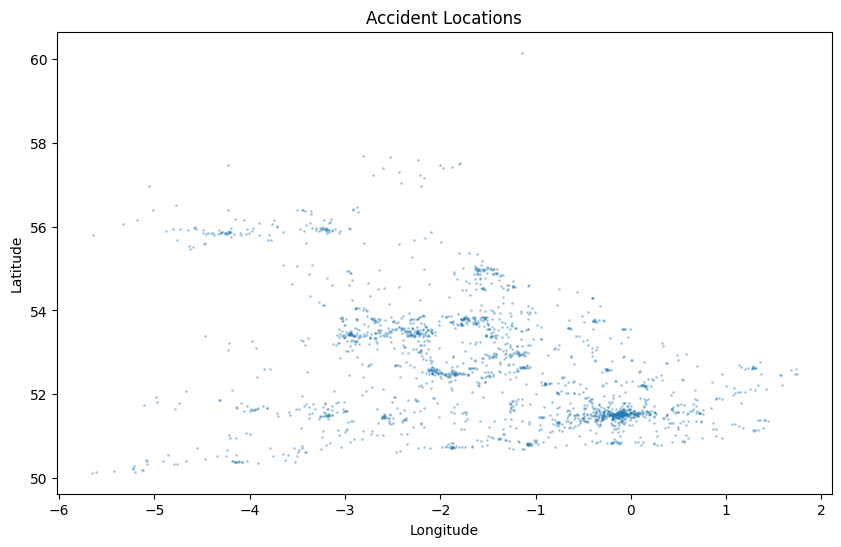

In [42]:
plt.figure(figsize=(10,6))
plt.scatter(df["Longitude"], df["Latitude"], s=1, alpha=0.3)
plt.title("Accident Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [43]:
from sklearn.cluster import DBSCAN
import numpy as np

coords = df[["Latitude", "Longitude"]].values

In [46]:
sample = df.sample(1000, random_state=42)
coords_sample = sample[["Latitude","Longitude"]].values

db = DBSCAN(eps=0.01, min_samples=50)
sample["cluster"] = db.fit_predict(coords_sample)

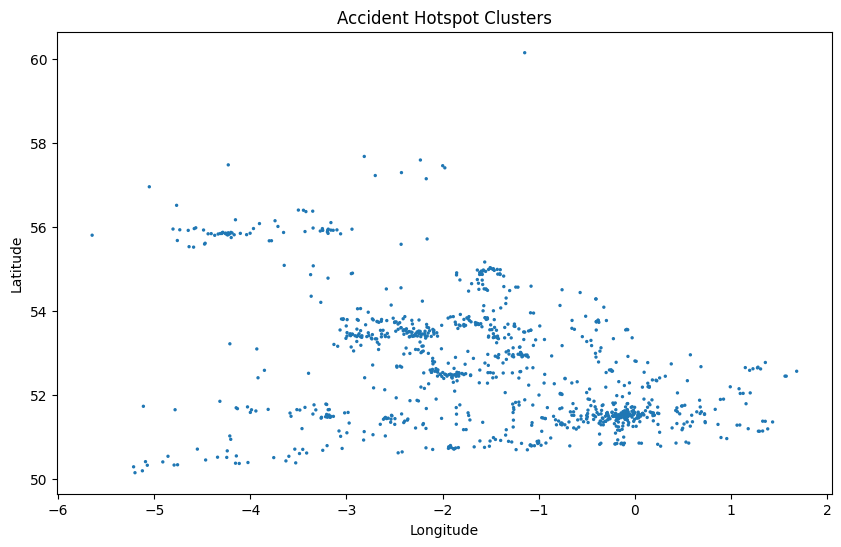

In [47]:
plt.figure(figsize=(10,6))
plt.scatter(sample["Longitude"], sample["Latitude"], 
            c=sample["cluster"], cmap="tab20", s=2)
plt.title("Accident Hotspot Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [48]:
sample["cluster"].value_counts().head(10)

cluster
-1    1000
Name: count, dtype: int64

In [49]:
sample["cluster"].nunique()

1

In [50]:
hotspots = sample[sample["cluster"] != -1]

centers = hotspots.groupby("cluster")[["Latitude","Longitude"]].mean()

centers.head()

,Latitude,Longitude
cluster,,


In [51]:
import sys
!{sys.executable} -m pip install folium

In [52]:
import folium
from folium.plugins import HeatMap

heat_data = sample[['Latitude', 'Longitude']].values.tolist()

m = folium.Map(location=[52.5, -1.5], zoom_start=6)

HeatMap(heat_data, radius=8).add_to(m)

m.save("accident_hotspots.html")

In [53]:
sample[['Hour','Rush_Hour','Night','Weekend']].head()

,Hour,Rush_Hour,Night,Weekend
256,0,0,1,1
352,21,0,1,0
298,22,0,1,0
581,23,0,1,0
1288,19,0,0,0


In [54]:
print(sample['Rush_Hour'].value_counts())
print(sample['Night'].value_counts())
sample['Weekend'].value_counts()

Rush_Hour
0    560
1    440
Name: count, dtype: int64
Night
0    837
1    163
Name: count, dtype: int64


Weekend
0    763
1    237
Name: count, dtype: int64

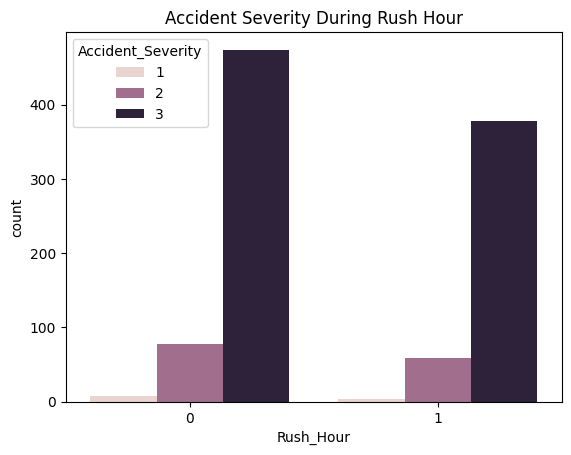

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Rush_Hour", hue="Accident_Severity", data=sample)

plt.title("Accident Severity During Rush Hour")
plt.show()

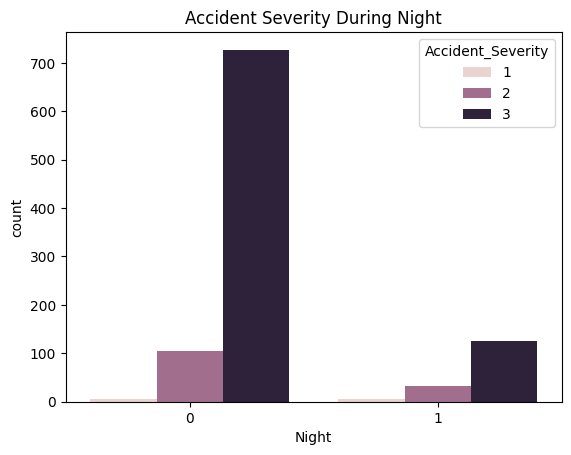

In [56]:
sns.countplot(x="Night", hue="Accident_Severity", data=sample)

plt.title("Accident Severity During Night")
plt.show()

In [57]:
severity_rush = pd.crosstab(
    sample["Rush_Hour"],
    sample["Accident_Severity"],
    normalize="index"
) * 100

severity_rush

Accident_Severity,1,2,3
Rush_Hour,,,
0,1.428571,13.928571,84.642857
1,0.681818,13.409091,85.909091


Rush hour increases accident frequency
but reduces accident severity.

In [58]:
severity_night = pd.crosstab(
    sample["Night"],
    sample["Accident_Severity"],
    normalize="index"
) * 100

severity_night

Accident_Severity,1,2,3
Night,,,
0,0.597372,12.544803,86.857826
1,3.680982,19.631902,76.687117


Night driving significantly increases accident severity.

Analysis shows that rush hour increases accident frequency but decreases severity due to lower vehicle speeds. In contrast, night-time driving significantly increases the proportion of fatal and serious accidents, likely due to reduced visibility and higher travel speeds.

In [59]:
df = sample.copy()
df = df.drop(columns=[
    "Accident_Index",
    "LSOA_of_Accident_Location",
    "Date"
], errors="ignore")

df.head()

,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Time,...,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year,Hour,Rush_Hour,Night,Weekend,cluster
256,497330.0,144350.0,-0.608617,51.190037,45,3,1,1,7,00:43,...,NaN,NaN,2,Yes,2006,0,0,1,1,-1
352,429220.0,438660.0,-1.557384,53.843366,13,3,2,1,5,21:00,...,NaN,NaN,1,Yes,2006,21,0,1,0,-1
298,552010.0,181370.0,0.189150,51.510759,1,3,1,1,3,22:35,...,NaN,NaN,2,Yes,2010,22,0,1,0,-1
581,408740.0,244020.0,-1.873848,52.094418,22,2,1,2,4,23:00,...,NaN,NaN,2,Yes,2010,23,0,1,0,-1
1288,535760.0,202990.0,-0.036499,51.709177,41,3,3,2,6,19:30,...,NaN,NaN,1,Yes,2010,19,0,0,0,-1


In [60]:
X = df.drop("Accident_Severity", axis=1)
y = df["Accident_Severity"]

In [61]:
X.select_dtypes(include="object").columns

Index(['Time', 'Local_Authority_(Highway)', 'Road_Type', 'Junction_Control',
       'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Did_Police_Officer_Attend_Scene_of_Accident'],
      dtype='object')

In [62]:
df = df.drop(columns=["Time", "Local_Authority_(Highway)"], errors="ignore")

In [63]:
categorical_cols = [
'Road_Type',
'Junction_Control',
'Pedestrian_Crossing-Human_Control',
'Pedestrian_Crossing-Physical_Facilities',
'Light_Conditions',
'Weather_Conditions',
'Road_Surface_Conditions',
'Special_Conditions_at_Site',
'Carriageway_Hazards',
'Did_Police_Officer_Attend_Scene_of_Accident'
]

One Hot Encoding

In [64]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [65]:
X = df_encoded.drop("Accident_Severity", axis=1)
y = df_encoded["Accident_Severity"]

In [66]:
df_encoded.shape

(1000, 59)

In [67]:
X.shape

(1000, 58)

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [69]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
y_pred = model.predict(X_test)

In [71]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.835

Confusion Matrix:
[[  0   0   1]
 [  0   0  32]
 [  0   0 167]]

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00        32
           3       0.83      1.00      0.91       167

    accuracy                           0.83       200
   macro avg       0.28      0.33      0.30       200
weighted avg       0.70      0.83      0.76       200



c:\Users\goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Class imbalance occured as majority cases are of severity 3, so model is mostly predicting severity 3.

In [72]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [73]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.835
[[  0   0   1]
 [  0   0  32]
 [  0   0 167]]
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00        32
           3       0.83      1.00      0.91       167

    accuracy                           0.83       200
   macro avg       0.28      0.33      0.30       200
weighted avg       0.70      0.83      0.76       200



c:\Users\goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\goyal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [74]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

importance.head(15)

,Feature,Importance
16,Hour,0.073224
2,Longitude,0.073214
1,Location_Northing_OSGR,0.072693
10,1st_Road_Number,0.071120
0,Location_Easting_OSGR,0.068986
8,Local_Authority_(District),0.063974
3,Latitude,0.061189
15,Year,0.051636
4,Police_Force,0.044548
7,Day_of_Week,0.042141


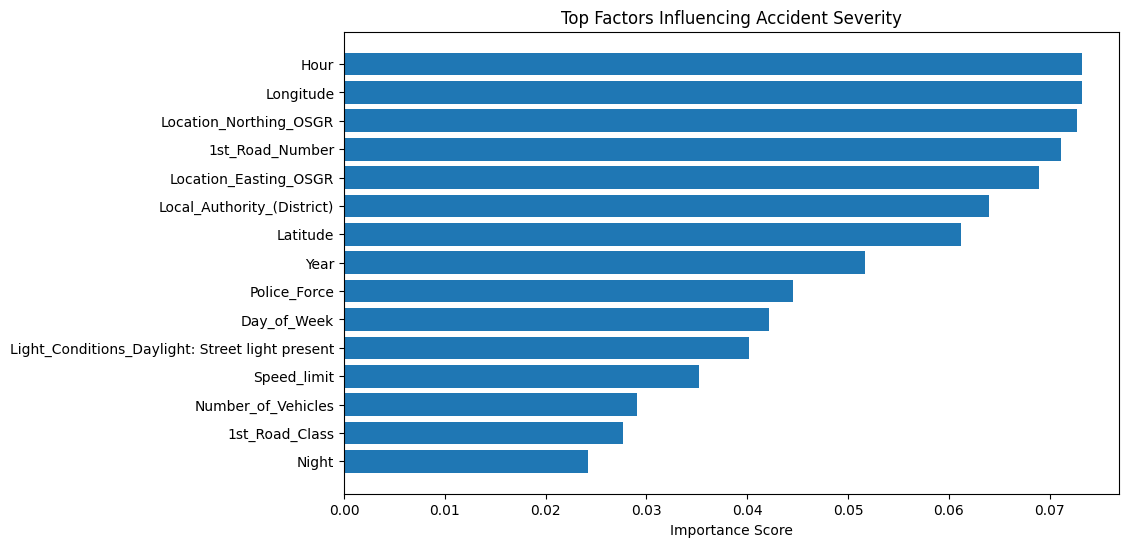

In [75]:
top_features = importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Factors Influencing Accident Severity")
plt.xlabel("Importance Score")
plt.show()

In [76]:
import pickle

with open("../app/accident_severity_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [82]:
feature_columns = X.columns

import pickle
pickle.dump(feature_columns, open("feature_columns.pkl","wb"))

In [79]:
import os

os.makedirs("app/sample_data", exist_ok=True)

df_sample = df.sample(1000, random_state=42)
df_sample.to_csv("app/sample_data/accidents_sample.csv", index=False)

In [ ]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load sample dataset
df = pd.read_csv("../sample_data/accidents_sample.csv")

# Example features (adjust if needed)
X = df.drop("accident_severity", axis=1)
y = df["accident_severity"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Save model
pickle.dump(model, open("app/accident_severity_model.pkl", "wb"))

# Save feature columns
pickle.dump(X.columns.tolist(), open("app/feature_columns.pkl", "wb"))

print("Model saved successfully")

KeyError: "['accident_severity'] not found in axis"